# Minimal DMC + Variational Evidence + Wong-Wang Pipeline

This notebook demonstrates a compact, CPU-runnable version of the current modeling pipeline:

- data input for one subject or a synthetic fallback;
- visual-feature or cached-logit style inputs;
- variational evidence sampling;
- DMC-style early flanker capture and late target control;
- Wong-Wang recurrent competition;
- response and RT readout;
- short training and held-out evaluation;
- report-style visualization.

It is an executable pedagogical example. It is **not** intended to reproduce the full paper/report numbers.

```mermaid
flowchart LR
    A[Data / one subject] --> B[Visual features or cached logits]
    B --> C[Variational evidence sampler]
    C --> D[DMC early flanker capture + late target control]
    D --> E[Wong-Wang recurrent competition]
    E --> F[RT / response readout]
    F --> G[Behavioral losses]
    G --> H[Evaluation plots]
```

## 1. Imports and plotting style

The notebook uses common scientific Python libraries only. The plotting settings below keep the style close to the current report figure: white background, black titles, muted condition colors, gray reference lines, and compact labels.

In [1]:
from pathlib import Path
import os
import json
import math
import random
import warnings

OUTPUT_DIR = Path("examples/outputs/dmc_var_ww_minimal")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / "mplconfig"))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "font.family": "DejaVu Sans",
    "figure.dpi": 130,
})

COLORS = {
    "correct_congruent": "#4C78A8",      # muted blue
    "correct_incongruent": "#59A14F",    # muted green
    "error_congruent": "#F28E2B",        # muted orange
    "error_incongruent": "#E6A157",      # muted amber-orange
    "all_trials": "#333333",
    "gray": "#9A9A9A",
    "light_gray": "#D6D6D6",
}

GROUP_SPECS = [
    (True, True, "correct_congruent", "Correct · Congruent"),
    (False, True, "correct_incongruent", "Correct · Incongruent"),
    (True, False, "error_congruent", "Error · Congruent"),
    (False, False, "error_incongruent", "Error · Incongruent"),
]

CLASS_NAMES = ["L", "R", "U", "D"]
CLASS_TO_INT = {name: i for i, name in enumerate(CLASS_NAMES)}
INT_TO_CLASS = {i: name for name, i in CLASS_TO_INT.items()}

def panel_label(ax, letter):
    ax.text(
        -0.12, 1.08, letter, transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top", ha="left", color="black"
    )

def condition_key(congruent, correct):
    if correct and congruent:
        return "correct_congruent"
    if correct and not congruent:
        return "correct_incongruent"
    if (not correct) and congruent:
        return "error_congruent"
    return "error_incongruent"

def gaussian_kde_manual(values, grid):
    # Small dependency-free KDE for teaching notebooks.
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return np.zeros_like(grid)
    sd = max(float(values.std(ddof=1)), 0.035)
    bandwidth = max(0.85 * sd * (len(values) ** (-1 / 5)), 0.025)
    z = (grid[:, None] - values[None, :]) / bandwidth
    density = np.exp(-0.5 * z ** 2).sum(axis=1)
    return density / (len(values) * bandwidth * np.sqrt(2 * np.pi))

## 2. Data input

The cell below first looks for the repository's small age-group CSV files and extracts one subject without exposing the raw subject identifier. If those files are unavailable, it creates a synthetic one-subject dataset with the same fields.

By default it uses real human trial rows and cached Stage-1 logits when they are present. It scans available subjects and chooses a subject with enough incongruent and error trials for a stable teaching example. If no single subject meets the criteria, the loader can build a small anonymized panel of 2-5 subjects.

The synthetic fallback is only a runnable backup for environments where the real CSV files cannot be shared. If fallback is used, plots and metrics are explicitly labeled as synthetic.

In [2]:
DATA_ROOT = Path("data/age_groups_matched")
AGE_GROUP = "20-29"
CHECKPOINT_ROOT = Path("artifacts/checkpoints/age_groups_matched")
USE_REAL_DATA = True
USE_SYNTHETIC_FALLBACK = True
SUBJECT_SELECTION_MODE = "small_panel"
N_SUBJECTS_PANEL = 3
MAX_TRAIN_TRIALS = 5000
MAX_TEST_TRIALS = 1500
RT_PLOT_MIN_SECONDS = 0.4
RT_PLOT_MAX_SECONDS = 1.0
FAST_DEV_RUN = False

MIN_TRIALS = 500
MIN_TEST = 150
MIN_TOTAL_ERRORS = 50
MIN_ERROR_CONGRUENT = 10
MIN_ERROR_INCONGRUENT = 10
MIN_INCONGRUENT_TRIALS = 100

if FAST_DEV_RUN:
    MAX_TRAIN_TRIALS = 1200
    MAX_TEST_TRIALS = 400

def _make_feature_bank(n_classes=4, feature_dim=16, seed=SEED):
    rng = np.random.default_rng(seed)
    prototypes = rng.normal(0, 0.5, size=(n_classes, feature_dim)).astype("float32")
    prototypes[:, :n_classes] += np.eye(n_classes, dtype="float32") * 2.0
    return prototypes

def _features_from_labels(target, flanker, congruent, feature_dim=16, seed=SEED):
    rng = np.random.default_rng(seed)
    prototypes = _make_feature_bank(4, feature_dim, seed)
    n = len(target)
    features = np.zeros((n, feature_dim), dtype="float32")
    for i in range(n):
        # The target contributes most of the feature signal.
        # In incongruent trials, the flanker contributes a smaller conflicting signal.
        flanker_weight = 0.25 if congruent[i] else 0.45
        features[i] = (
            1.00 * prototypes[target[i]]
            + flanker_weight * prototypes[flanker[i]]
            + rng.normal(0, 0.35, size=feature_dim)
        )
    return features

def _logits_from_features(features, target, flanker, congruent, seed=SEED):
    rng = np.random.default_rng(seed + 1)
    n_classes = 4
    w = rng.normal(0, 0.12, size=(features.shape[1], n_classes)).astype("float32")
    for c in range(n_classes):
        w[c, c] += 0.9
    logits = features @ w
    for i in range(len(target)):
        logits[i, target[i]] += 1.1
        logits[i, flanker[i]] += 0.45 if congruent[i] else 0.85
        logits[i] += rng.normal(0, 0.45, size=n_classes)
    return logits.astype("float32")

def _read_real_split(split_name):
    csv_candidates = [
        DATA_ROOT / AGE_GROUP / f"{split_name}_data.csv",
        Path("data/age_groups") / AGE_GROUP / f"{split_name}_data.csv",
    ]
    csv_path = next((path for path in csv_candidates if path.exists()), None)
    if csv_path is None:
        return None
    df = pd.read_csv(csv_path)
    required = {"target_direction", "flanker_direction", "response_direction", "response_time", "anon_id"}
    if not required.issubset(df.columns):
        return None
    df = df.loc[
        df["target_direction"].isin(CLASS_TO_INT)
        & df["flanker_direction"].isin(CLASS_TO_INT)
        & df["response_direction"].isin(CLASS_TO_INT)
    ].copy()
    df["source_split"] = split_name
    df["row_in_source_split"] = np.arange(len(df))
    df["target_labels"] = df["target_direction"].map(CLASS_TO_INT).astype(np.int64)
    df["flanker_labels"] = df["flanker_direction"].map(CLASS_TO_INT).astype(np.int64)
    df["response_labels"] = df["response_direction"].map(CLASS_TO_INT).astype(np.int64)
    df["true_rt"] = (df["response_time"].astype("float32") / 1000.0).clip(0.20, 2.50)
    df["congruency"] = (df["target_labels"] == df["flanker_labels"]).astype(np.int64)
    df["human_correct"] = df["response_labels"] == df["target_labels"]

    logits_candidates = [
        CHECKPOINT_ROOT / AGE_GROUP / "stage2" / f"{split_name}_logits.npz",
        Path("artifacts/checkpoints/age_groups") / AGE_GROUP / "stage2" / f"{split_name}_logits.npz",
    ]
    logits_path = next((path for path in logits_candidates if path.exists()), None)
    if logits_path is not None and logits_path.exists():
        cached = np.load(logits_path)
        if "logits" in cached and cached["logits"].shape[0] >= len(df):
            logits = cached["logits"][:len(df)].astype("float32")
            for j in range(logits.shape[1]):
                df[f"logit_{j}"] = logits[:, j]
            df["feature_source"] = "cached_stage1_logits"
    return df

def _summarize_subjects(df):
    rows = []
    for subject_id, group in df.groupby("anon_id"):
        errors = ~group["human_correct"]
        incongruent = group["congruency"] == 0
        rows.append({
            "anon_id": subject_id,
            "n_trials": int(len(group)),
            "human_error_total": int(errors.sum()),
            "human_error_congruent": int((errors & ~incongruent).sum()),
            "human_error_incongruent": int((errors & incongruent).sum()),
            "incongruent_trials": int(incongruent.sum()),
            "score": float(errors.sum() * 4 + (errors & ~incongruent).sum() * 6 + (errors & incongruent).sum() * 6 + incongruent.sum() * 0.05),
        })
    return pd.DataFrame(rows).sort_values("score", ascending=False)

def _select_teaching_rows(df):
    subject_summary = _summarize_subjects(df)
    eligible = subject_summary.loc[
        (subject_summary["n_trials"] >= MIN_TRIALS)
        & (subject_summary["human_error_total"] >= MIN_TOTAL_ERRORS)
        & (subject_summary["human_error_congruent"] >= MIN_ERROR_CONGRUENT)
        & (subject_summary["human_error_incongruent"] >= MIN_ERROR_INCONGRUENT)
        & (subject_summary["incongruent_trials"] >= MIN_INCONGRUENT_TRIALS)
    ]
    if SUBJECT_SELECTION_MODE == "single_subject" and len(eligible):
        selected_subjects = [eligible.iloc[0]["anon_id"]]
        selection_note = "single real subject selected by error/congruency coverage"
    else:
        pool = eligible if len(eligible) else subject_summary
        selected_subjects = pool.head(N_SUBJECTS_PANEL)["anon_id"].tolist()
        selection_note = "small real-data panel selected for stable condition-level diagnostics"

    panel = df.loc[df["anon_id"].isin(selected_subjects)].copy()
    anonymized_map = {sid: f"S{i+1:02d}" for i, sid in enumerate(selected_subjects)}
    panel["subject_id_anonymized"] = panel["anon_id"].map(anonymized_map)

    # Stratified real-data subset keeps the example fast while preserving all diagnostic groups.
    desired = {
        "correct_congruent": int((MAX_TRAIN_TRIALS + MAX_TEST_TRIALS) * 0.30),
        "correct_incongruent": int((MAX_TRAIN_TRIALS + MAX_TEST_TRIALS) * 0.30),
        "error_congruent": int((MAX_TRAIN_TRIALS + MAX_TEST_TRIALS) * 0.18),
        "error_incongruent": int((MAX_TRAIN_TRIALS + MAX_TEST_TRIALS) * 0.22),
    }
    chosen = []
    rng = np.random.default_rng(SEED)
    for congruent, correct, key, _label in GROUP_SPECS:
        mask = (panel["congruency"].astype(bool) == congruent) & (panel["human_correct"].astype(bool) == correct)
        group_idx = panel.loc[mask].index.to_numpy()
        take = min(len(group_idx), desired[key])
        if take > 0:
            chosen.extend(rng.choice(group_idx, size=take, replace=False).tolist())
    chosen = rng.permutation(chosen)
    max_trials = MAX_TRAIN_TRIALS + MAX_TEST_TRIALS
    if len(chosen) > max_trials:
        chosen = chosen[:max_trials]
    out = panel.loc[chosen].copy().reset_index(drop=True)
    out["trial_index"] = np.arange(len(out))
    return out, selected_subjects, selection_note, subject_summary

def _build_real_dataset():
    frames = []
    for split_name in ("train", "test"):
        split_df = _read_real_split(split_name)
        if split_df is not None:
            frames.append(split_df)
    if not frames:
        return None
    raw = pd.concat(frames, ignore_index=True)
    selected, selected_subjects, selection_note, subject_summary = _select_teaching_rows(raw)
    logit_cols = [f"logit_{i}" for i in range(4)]
    if all(col in selected.columns for col in logit_cols):
        logits = selected[logit_cols].to_numpy(dtype=np.float32)
        features = logits.copy()
        feature_source = "cached_stage1_logits"
    else:
        target = selected["target_labels"].to_numpy(dtype=np.int64)
        flanker = selected["flanker_labels"].to_numpy(dtype=np.int64)
        congruent = selected["congruency"].to_numpy(dtype=bool)
        features = _features_from_labels(target, flanker, congruent, feature_dim=16, seed=SEED)
        logits = _logits_from_features(features, target, flanker, congruent, seed=SEED)
        feature_source = "label-derived public-safe features"

    table = selected[[
        "trial_index", "subject_id_anonymized", "target_labels", "flanker_labels",
        "response_labels", "true_rt", "congruency", "human_correct"
    ]].copy()
    table["rts"] = table["true_rt"]
    return {
        "source": f"real CSV rows from {DATA_ROOT.as_posix()}/{AGE_GROUP} with {feature_source}",
        "subject_selection": selection_note,
        "n_subjects": int(len(selected_subjects)),
        "age_group": AGE_GROUP,
        "subject_summary": subject_summary.drop(columns=["anon_id"]).head(10).to_dict(orient="records"),
        "table": table,
        "features": features.astype("float32"),
        "logits": logits.astype("float32"),
        "is_synthetic": False,
    }

def _build_synthetic_dataset(max_trials=1200):
    rng = np.random.default_rng(SEED)
    # The fallback is balanced enough for density plots and fast-error diagnostics.
    # These counts ensure both error groups have at least 10 trials.
    requested_counts = {
        (True, True): 125,    # correct congruent
        (False, True): 125,   # correct incongruent
        (True, False): 45,    # error congruent
        (False, False): 65,   # error incongruent
    }
    scale = min(1.0, max_trials / sum(requested_counts.values()))
    counts = {k: max(10 if not k[1] else 30, int(round(v * scale))) for k, v in requested_counts.items()}

    target_rows, flanker_rows, response_rows, congruent_rows, correct_rows, rt_rows = [], [], [], [], [], []
    for (is_congruent, is_correct), count in counts.items():
        for _ in range(count):
            tgt = int(rng.integers(0, 4))
            if is_congruent:
                flk = tgt
            else:
                flk = int(rng.choice([c for c in range(4) if c != tgt]))
            if is_correct:
                resp = tgt
            elif not is_congruent:
                resp = flk
            else:
                resp = int(rng.choice([c for c in range(4) if c != tgt]))

            # Right-tailed RTs: gamma noise adds a long positive tail.
            rt = 0.40 + rng.gamma(shape=2.1, scale=0.070)
            if not is_congruent and is_correct:
                rt += 0.060
            if not is_correct:
                rt -= 0.045
                if not is_congruent:
                    rt += 0.020
            rt += rng.normal(0, 0.020)

            target_rows.append(tgt)
            flanker_rows.append(flk)
            response_rows.append(resp)
            congruent_rows.append(is_congruent)
            correct_rows.append(is_correct)
            rt_rows.append(rt)

    target = np.asarray(target_rows, dtype=np.int64)
    flanker = np.asarray(flanker_rows, dtype=np.int64)
    response = np.asarray(response_rows, dtype=np.int64)
    congruent = np.asarray(congruent_rows, dtype=bool)
    rts = np.clip(np.asarray(rt_rows, dtype=np.float32), 0.25, 1.8)

    order = rng.permutation(len(target))
    target, flanker, response, congruent, rts = (
        target[order], flanker[order], response[order], congruent[order], rts[order]
    )

    features = _features_from_labels(target, flanker, congruent, feature_dim=16, seed=SEED)
    logits = _logits_from_features(features, target, flanker, congruent, seed=SEED)
    out = pd.DataFrame({
        "trial_index": np.arange(len(target)),
        "subject_id_anonymized": "synthetic_S01",
        "target_labels": target,
        "flanker_labels": flanker,
        "response_labels": response,
        "true_rt": rts,
        "congruency": congruent.astype(np.int64),
    })
    out["rts"] = out["true_rt"]
    out["human_correct"] = out["response_labels"] == out["target_labels"]
    return {
        "source": "synthetic fallback with real-data field structure",
        "subject_selection": "synthetic fallback; no real subject selected",
        "n_subjects": 1,
        "age_group": AGE_GROUP,
        "subject_summary": [],
        "table": out,
        "features": features,
        "logits": logits,
        "is_synthetic": True,
    }

data = _build_real_dataset() if USE_REAL_DATA else None
if data is None:
    if not USE_SYNTHETIC_FALLBACK:
        raise FileNotFoundError("Real data not found and USE_SYNTHETIC_FALLBACK is False.")
    data = _build_synthetic_dataset(max_trials=1200)

trials = data["table"]
print(data["source"])
print(data["subject_selection"], "| n_subjects:", data["n_subjects"])
if data["is_synthetic"]:
    print("Synthetic fallback note: balanced for teaching plots only; not a real experimental result.")
print(trials.head())
print({
    "n_trials": len(trials),
    "accuracy": float((trials.response_labels == trials.target_labels).mean()),
    "group_counts": {
        key: int(((trials["congruency"].astype(bool) == congruent) & (trials["human_correct"].astype(bool) == correct)).sum())
        for congruent, correct, key, _label in GROUP_SPECS
    },
})

real CSV rows from data/age_groups_matched/20-29 with cached_stage1_logits
small real-data panel selected for stable condition-level diagnostics | n_subjects: 3
   trial_index subject_id_anonymized  target_labels  flanker_labels  \
0            0                   S02              2               3   
1            1                   S01              3               0   
2            2                   S03              1               3   
3            3                   S01              3               1   
4            4                   S02              1               1   

   response_labels  true_rt  congruency  human_correct    rts  
0                3    0.530           0          False  0.530  
1                3    0.766           0           True  0.766  
2                1    0.528           0           True  0.528  
3                2    0.656           0          False  0.656  
4                1    0.701           1           True  0.701  
{'n_trials': 6214, 'accuracy

## 3. Variational evidence sampler

The sampler maps feature-like inputs into a mean and log variance, then uses the reparameterization trick to produce a time-varying evidence sequence. Uncertainty is injected at the evidence-encoding stage because ambiguous visual input should affect the entire decision trajectory, not only the final choice.

## Variational evidence sampling: connection to VAE

In a standard VAE, the encoder does not output a single deterministic latent variable.
Instead, it outputs the parameters of a distribution:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))
$$

A latent sample is then drawn from this distribution:

$$
z \sim \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))
$$

Direct sampling makes backpropagation difficult, so VAEs use the reparameterization trick:

$$
z = \mu_\phi(x) + \sigma_\phi(x)\epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
$$

The randomness is isolated in \(\epsilon\), while \(\mu_\phi(x)\) and \(\sigma_\phi(x)\) remain differentiable and can be updated by gradient descent.

A standard VAE is usually trained with:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{reconstruction}
+
\mathrm{KL}\left(q_\phi(z \mid x)\,\|\,p(z)\right)
$$
In this notebook, however, we are not implementing a full VAE.
There is no decoder that reconstructs the input image, and we do not use a standard VAE reconstruction loss or KL loss.

Instead, we use a VAE-inspired variational evidence sampler:
the encoder outputs an evidence mean and evidence uncertainty, samples a time-varying evidence sequence, and sends that sampled evidence into the DMC + Wong-Wang decision model.

The training target is therefore behavioral:

- response choice
- reaction time
- RT distribution shape
- congruency effect
- error-vs-correct RT pattern

So the variational component is used as a mechanism for evidence-level uncertainty, not as a full generative image model.

In [3]:
class VariationalEvidenceSampler(nn.Module):
    def __init__(self, feature_dim=16, n_classes=4, hidden_dim=48):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # mean_head outputs the evidence mean, analogous to mu_phi(x).
        self.mean_head = nn.Linear(hidden_dim, n_classes)
        # logvar_head outputs evidence uncertainty, analogous to log sigma_phi^2(x).
        self.logvar_head = nn.Linear(hidden_dim, n_classes)

    def forward(self, features, time_steps=80, uncertainty_gain=0.85, correlated_noise=False, rho=0.80):
        hidden = self.encoder(features)
        mean = self.mean_head(hidden)
        logvar = self.logvar_head(hidden).clamp(-5.0, 1.2)
        # std = exp(0.5 * logvar), as in VAE-style Gaussian sampling.
        std = torch.exp(0.5 * logvar) * float(uncertainty_gain)
        eps = torch.randn(features.shape[0], time_steps, mean.shape[-1], device=features.device)
        if correlated_noise:
            # Optional AR(1) evidence noise: eta_t = rho * eta_{t-1} + sigma_t * epsilon_t.
            # The main demo leaves this off, but it is useful for extensions.
            eta = torch.zeros_like(eps)
            eta[:, 0, :] = eps[:, 0, :]
            for t in range(1, time_steps):
                eta[:, t, :] = float(rho) * eta[:, t - 1, :] + math.sqrt(1 - float(rho) ** 2) * eps[:, t, :]
            eps = eta
        # Reparameterization trick: evidence = mean + std * epsilon.
        # This is VAE-inspired evidence sampling, not a full VAE: there is no decoder or KL term here.
        evidence_samples = mean.unsqueeze(1) + std.unsqueeze(1) * eps
        return {
            "mean": mean,
            "logvar": logvar,
            "evidence_samples": evidence_samples,
        }

## 4. DMC-style conflict modulation

The DMC-style part adds directional conflict over time:

- an early alpha pulse boosts the flanker-consistent class;
- a late sigmoid gate suppresses the flanker class;
- the target class can receive a mild late boost;
- by default, this modulation is applied only to incongruent trials.

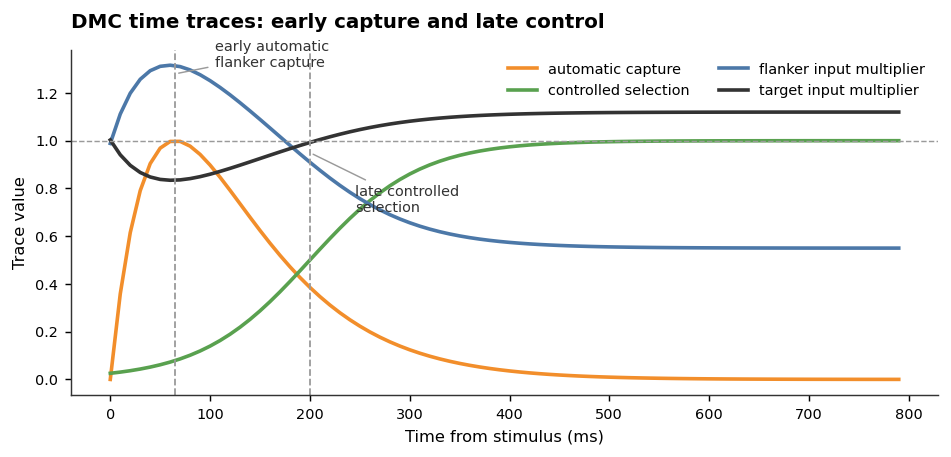

examples/outputs/dmc_var_ww_minimal/example_dmc_traces.png


In [4]:
def alpha_pulse(time_axis, peak_s=0.065):
    peak = max(float(peak_s), 1e-6)
    scaled = time_axis / peak
    return scaled * torch.exp(1.0 - scaled)

def build_dmc_traces(time_steps=80, dt_s=0.01, auto_strength=0.35,
                     auto_peak_s=0.065, selection_strength=0.45,
                     selection_midpoint_s=0.20, selection_tau_s=0.055,
                     target_boost=0.12, device=DEVICE):
    t = torch.arange(time_steps, device=device, dtype=torch.float32) * dt_s
    auto = alpha_pulse(t, peak_s=auto_peak_s)
    gate = torch.sigmoid((t - selection_midpoint_s) / max(selection_tau_s, 1e-6))
    flanker_multiplier = (1.0 + auto_strength * auto - selection_strength * gate).clamp_min(0.0)
    target_multiplier = (1.0 - 0.5 * auto_strength * auto + target_boost * gate).clamp_min(0.0)
    return {
        "time": t,
        "auto_pulse": auto,
        "selection_gate": gate,
        "flanker_multiplier": flanker_multiplier,
        "target_multiplier": target_multiplier,
    }

def apply_dmc_modulation(evidence, target_labels, flanker_labels, apply_to="incongruent_only", **kwargs):
    modulated = evidence.clone()
    B, T, C = modulated.shape
    traces = build_dmc_traces(time_steps=T, device=evidence.device, **kwargs)

    if apply_to == "incongruent_only":
        trial_mask = target_labels != flanker_labels
    elif apply_to == "all_trials":
        trial_mask = torch.ones(B, device=evidence.device, dtype=torch.bool)
    else:
        raise ValueError(f"Unknown apply_to: {apply_to}")

    idx = torch.nonzero(trial_mask, as_tuple=False).squeeze(1)
    if idx.numel() > 0:
        time_idx = torch.arange(T, device=evidence.device).unsqueeze(0).expand(idx.numel(), T)
        flanker_idx = flanker_labels[idx].unsqueeze(1)
        target_idx = target_labels[idx].unsqueeze(1)
        modulated[idx.unsqueeze(1), time_idx, flanker_idx] *= traces["flanker_multiplier"].unsqueeze(0)
        modulated[idx.unsqueeze(1), time_idx, target_idx] *= traces["target_multiplier"].unsqueeze(0)

    traces["trial_mask"] = trial_mask
    return modulated, traces

dmc_kwargs = {
    "auto_peak_s": 0.065,
    "selection_midpoint_s": 0.20,
}
dmc_traces = build_dmc_traces(**dmc_kwargs)
fig, ax = plt.subplots(figsize=(7.2, 3.4), constrained_layout=True)
time_ms = dmc_traces["time"].detach().numpy() * 1000
ax.plot(time_ms, dmc_traces["auto_pulse"].detach().numpy(), color=COLORS["error_congruent"], lw=2.0, label="automatic capture")
ax.plot(time_ms, dmc_traces["selection_gate"].detach().numpy(), color=COLORS["correct_incongruent"], lw=2.0, label="controlled selection")
ax.plot(time_ms, dmc_traces["flanker_multiplier"].detach().numpy(), color=COLORS["correct_congruent"], lw=2.0, label="flanker input multiplier")
ax.plot(time_ms, dmc_traces["target_multiplier"].detach().numpy(), color=COLORS["all_trials"], lw=2.0, label="target input multiplier")
ax.axhline(1.0, color=COLORS["gray"], lw=0.8, ls="--")
ax.axvline(dmc_kwargs["auto_peak_s"] * 1000, color=COLORS["gray"], lw=1.0, ls="--")
ax.axvline(dmc_kwargs["selection_midpoint_s"] * 1000, color=COLORS["gray"], lw=1.0, ls="--")
ax.annotate("early automatic\nflanker capture", xy=(dmc_kwargs["auto_peak_s"] * 1000, 1.28),
            xytext=(105, 1.31), arrowprops={"arrowstyle": "-", "color": COLORS["gray"], "lw": 0.8},
            fontsize=8, color="#333333")
ax.annotate("late controlled\nselection", xy=(dmc_kwargs["selection_midpoint_s"] * 1000, 0.95),
            xytext=(245, 0.70), arrowprops={"arrowstyle": "-", "color": COLORS["gray"], "lw": 0.8},
            fontsize=8, color="#333333")
ax.set_title("DMC time traces: early capture and late control", loc="left", pad=12)
ax.set_xlabel("Time from stimulus (ms)")
ax.set_ylabel("Trace value")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2)
dmc_trace_path = OUTPUT_DIR / "example_dmc_traces.png"
fig.savefig(dmc_trace_path, bbox_inches="tight")
plt.show()
print(dmc_trace_path)

## 5. Minimal Wong-Wang decision module and readout

This simplified module keeps the key role of the full model: evidence is accumulated through interacting response populations. It is not a strict independent race model. The readout is race-like, but the populations interact through self-excitation and lateral inhibition before the response and RT are read out.

In [5]:
class MinimalWongWang(nn.Module):
    def __init__(self, n_classes=4, dt_s=0.01, self_excitation=1.15,
                 lateral_inhibition=0.42, leak=0.20, threshold=1.0):
        super().__init__()
        self.n_classes = n_classes
        self.dt_s = dt_s
        self.log_input_gain = nn.Parameter(torch.tensor(math.log(0.95), dtype=torch.float32))
        self.self_excitation = nn.Parameter(torch.tensor(self_excitation, dtype=torch.float32))
        self.lateral_inhibition = nn.Parameter(torch.tensor(lateral_inhibition, dtype=torch.float32))
        self.leak = nn.Parameter(torch.tensor(leak, dtype=torch.float32))
        self.threshold = nn.Parameter(torch.tensor(threshold, dtype=torch.float32), requires_grad=False)
        self.noise_scale = 0.025

    def forward(self, evidence, add_noise=False):
        B, T, C = evidence.shape
        state = torch.zeros(B, C, device=evidence.device)
        trajectory = []
        input_gain = torch.exp(self.log_input_gain)
        offdiag = torch.ones(C, C, device=evidence.device) - torch.eye(C, device=evidence.device)
        recurrent = self.self_excitation * torch.eye(C, device=evidence.device) - self.lateral_inhibition * offdiag

        for t in range(T):
            drive = input_gain * F.softplus(evidence[:, t, :])
            rec = state @ recurrent
            noise = torch.randn_like(state) * self.noise_scale if add_noise else 0.0
            # Rectified state dynamics keep population activity non-negative.
            delta = -F.softplus(self.leak) * state + F.relu(drive + rec + noise)
            state = F.relu(state + self.dt_s * delta)
            trajectory.append(state)

        return torch.stack(trajectory, dim=1)

def soft_rt_choice_readout(trajectory, dt_s=0.01, t0=0.23, threshold=1.0, temperature=0.08):
    B, T, C = trajectory.shape
    time = torch.arange(T, device=trajectory.device, dtype=trajectory.dtype) * dt_s
    # A soft crossing score emphasizes early above-threshold activity but remains differentiable.
    crossing_score = torch.sigmoid((trajectory - threshold) / temperature)
    hazard = crossing_score.max(dim=-1).values
    weights = hazard + 1e-4
    pred_decision_time = (weights * time.unsqueeze(0)).sum(dim=1) / weights.sum(dim=1)
    pred_rt = pred_decision_time + float(t0)

    class_strength = trajectory.max(dim=1).values
    choice_logits = class_strength / max(float(temperature), 1e-6)
    choice_probs = torch.softmax(choice_logits, dim=-1)
    pred_choice = choice_probs.argmax(dim=-1)
    return {
        "pred_rt": pred_rt,
        "choice_logits": choice_logits,
        "choice_probs": choice_probs,
        "pred_choice": pred_choice,
        "class_strength": class_strength,
    }

class MinimalDMCVarWWModel(nn.Module):
    def __init__(self, feature_dim=16, n_classes=4, time_steps=80, dt_s=0.01):
        super().__init__()
        self.n_classes = n_classes
        self.time_steps = time_steps
        self.dt_s = dt_s
        self.sampler = VariationalEvidenceSampler(feature_dim=feature_dim, n_classes=n_classes)
        self.ww = MinimalWongWang(n_classes=n_classes, dt_s=dt_s)
        self.t0_raw = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.rt_readout_head = nn.Sequential(
            nn.Linear(n_classes * 2 + 3, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, features, target_labels, flanker_labels, uncertainty_gain=0.85, add_noise=False, add_rt_noise=True, sample_choice=True):
        sample = self.sampler(features, time_steps=self.time_steps, uncertainty_gain=uncertainty_gain)
        evidence, traces = apply_dmc_modulation(
            sample["evidence_samples"],
            target_labels=target_labels,
            flanker_labels=flanker_labels,
            dt_s=self.dt_s,
            apply_to="incongruent_only",
        )
        trajectory = self.ww(evidence, add_noise=add_noise)
        t0 = 0.18 + 0.18 * torch.sigmoid(self.t0_raw)
        readout = soft_rt_choice_readout(
            trajectory,
            dt_s=self.dt_s,
            t0=float(t0.detach()) if not self.training else t0,
            threshold=float(self.ww.threshold.detach()),
        )
        # A small fixed lapse component makes choice readout stochastic instead of pure argmax.
        # This is a simplified stand-in for residual motor/attention variability.
        lapse_rate = 0.12
        readout["choice_probs"] = (1.0 - lapse_rate) * readout["choice_probs"] + lapse_rate / self.n_classes
        readout["choice_logits"] = (readout["choice_probs"] + 1e-8).log()
        if sample_choice:
            readout["pred_choice"] = torch.multinomial(readout["choice_probs"], num_samples=1).squeeze(1)
        else:
            readout["pred_choice"] = readout["choice_probs"].argmax(dim=-1)
        # A small learned RT calibration head uses only model-internal trajectory/evidence summaries.
        # It helps the teaching model match distribution shape without feeding human RT as input.
        entropy = -(readout["choice_probs"] * readout["choice_probs"].clamp_min(1e-8).log()).sum(dim=-1, keepdim=True)
        traj_summary = torch.cat([
            readout["class_strength"],
            sample["mean"],
            sample["logvar"].mean(dim=-1, keepdim=True),
            entropy,
            readout["class_strength"].amax(dim=-1, keepdim=True),
        ], dim=-1)
        rt_head = self.rt_readout_head(traj_summary)
        rt_offset = 0.70 * torch.sigmoid(rt_head[:, 0]) - 0.25
        # Stochastic readout scale is a minimal stand-in for trial-level residual variability.
        # It is trained only from train-set behavioral losses, never from held-out RT inputs.
        rt_scale = 0.015 + 0.22 * torch.sigmoid(rt_head[:, 1])
        if add_rt_noise:
            rt_residual = rt_scale * torch.randn_like(rt_scale)
        else:
            rt_residual = torch.zeros_like(rt_scale)
        readout["pred_rt"] = (readout["pred_rt"] + rt_offset + rt_residual).clamp(0.20, 2.20)
        readout["pred_rt_scale"] = rt_scale
        return {
            **readout,
            "trajectory": trajectory,
            "evidence": evidence,
            "mean": sample["mean"],
            "logvar": sample["logvar"],
            "dmc_traces": traces,
        }

## 6. Training loop

The model is trained on the train split only. Human RT is used as a training target, never as a model input.

The loss combines:

- `response_nll`: encourages the model to predict the observed response;
- `rt_mse`: fits trial-level RT;
- `congruency_gap_loss`: matches the human incongruent-minus-congruent RT gap;
- `error_gap_loss`: matches the human error-minus-correct RT gap when enough errors are present in the batch;
- `tail_or_quantile_loss`: matches multiple RT quantiles `[0.1, 0.25, 0.5, 0.75, 0.9]`, not just the mean;
- `condition_mean_loss`: matches condition-level mean RT for correct/error × congruent/incongruent groups.

The goal is a runnable real-data fitting example, not a final production-quality fit.

In [6]:
features_np = data["features"].astype("float32")
logits_np = data["logits"].astype("float32")
target_np = trials["target_labels"].to_numpy(dtype=np.int64)
flanker_np = trials["flanker_labels"].to_numpy(dtype=np.int64)
response_np = trials["response_labels"].to_numpy(dtype=np.int64)
rt_np = trials["true_rt"].to_numpy(dtype=np.float32)

n = len(trials)
rng = np.random.default_rng(SEED)
test_parts, train_parts = [], []
# Stratify the held-out split so final plots are based on real test rows with enough error trials.
for congruent, correct, key, _label in GROUP_SPECS:
    idx = trials.index[
        (trials["congruency"].astype(bool) == congruent)
        & (trials["human_correct"].astype(bool) == correct)
    ].to_numpy()
    idx = rng.permutation(idx)
    target_test_fraction = MAX_TEST_TRIALS / max(MAX_TRAIN_TRIALS + MAX_TEST_TRIALS, 1)
    n_test_group = max(10 if not correct else 40, int(round(target_test_fraction * len(idx))))
    n_test_group = min(n_test_group, len(idx) // 2 if len(idx) > 1 else len(idx))
    test_parts.append(idx[:n_test_group])
    train_parts.append(idx[n_test_group:])
test_idx = rng.permutation(np.concatenate(test_parts))[:MAX_TEST_TRIALS]
train_idx = rng.permutation(np.concatenate(train_parts))[:MAX_TRAIN_TRIALS]

X = torch.tensor(features_np, dtype=torch.float32, device=DEVICE)
y_target = torch.tensor(target_np, dtype=torch.long, device=DEVICE)
y_flanker = torch.tensor(flanker_np, dtype=torch.long, device=DEVICE)
y_response = torch.tensor(response_np, dtype=torch.long, device=DEVICE)
y_rt = torch.tensor(rt_np, dtype=torch.float32, device=DEVICE)

model = MinimalDMCVarWWModel(feature_dim=X.shape[1], time_steps=80, dt_s=0.01).to(DEVICE)
EPOCHS = 80 if not FAST_DEV_RUN else 12
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

train_human_correct = y_response[torch.tensor(train_idx, dtype=torch.long, device=DEVICE)] == y_target[torch.tensor(train_idx, dtype=torch.long, device=DEVICE)]
n_train_errors = int((~train_human_correct).sum().item())
use_error_gap_loss = n_train_errors >= 5
error_gap_warning = None
if not use_error_gap_loss:
    error_gap_warning = f"Skipped error_gap_loss because the training split has only {n_train_errors} human error trials."
    print("Warning:", error_gap_warning)

def _mean_gap(pred_rt, true_rt, mask_a, mask_b):
    if mask_a.sum() < 4 or mask_b.sum() < 4:
        return pred_rt.new_zeros(()), False
    model_gap = pred_rt[mask_a].mean() - pred_rt[mask_b].mean()
    human_gap = true_rt[mask_a].mean() - true_rt[mask_b].mean()
    return (model_gap - human_gap).pow(2), True

def _condition_mean_loss(pred_rt, true_rt, congruency, human_correct_mask):
    losses = []
    for is_congruent, is_correct, _key, _label in GROUP_SPECS:
        mask = (congruency.bool() == is_congruent) & (human_correct_mask.bool() == is_correct)
        if mask.sum() >= 4:
            losses.append((pred_rt[mask].mean() - true_rt[mask].mean()).pow(2))
    if not losses:
        return pred_rt.new_zeros(())
    return torch.stack(losses).mean()

def behavioral_distribution_losses(pred_rt, pred_choice, target_labels, response_labels, true_rt, congruency):
    # These losses compare distribution-level behavioral summaries on train batches only.
    human_correct_mask = response_labels == target_labels
    incongruent_mask = congruency == 0
    congruency_gap_loss, used_cong = _mean_gap(pred_rt, true_rt, incongruent_mask, ~incongruent_mask)
    error_gap_loss, used_error = _mean_gap(pred_rt, true_rt, ~human_correct_mask, human_correct_mask)

    quantiles = torch.tensor([0.10, 0.25, 0.50, 0.75, 0.90], device=pred_rt.device)
    pred_q = torch.quantile(pred_rt, quantiles)
    true_q = torch.quantile(true_rt, quantiles)
    tail_or_quantile_loss = (pred_q - true_q).pow(2).mean()
    condition_mean_loss = _condition_mean_loss(pred_rt, true_rt, congruency, human_correct_mask)
    return {
        "congruency_gap_loss": congruency_gap_loss,
        "error_gap_loss": error_gap_loss,
        "tail_or_quantile_loss": tail_or_quantile_loss,
        "condition_mean_loss": condition_mean_loss,
        "used_congruency_gap": used_cong,
        "used_error_gap": used_error,
    }

history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_rows = []
    for start in range(0, len(train_idx), BATCH_SIZE):
        idx = train_idx[start:start + BATCH_SIZE]
        idx_t = torch.tensor(idx, dtype=torch.long, device=DEVICE)
        out = model(X[idx_t], y_target[idx_t], y_flanker[idx_t], uncertainty_gain=0.75, add_noise=False)

        response_loss = F.cross_entropy(out["choice_logits"], y_response[idx_t])
        rt_mse = F.mse_loss(out["pred_rt"], y_rt[idx_t])
        dist_losses = behavioral_distribution_losses(
            out["pred_rt"], out["pred_choice"], y_target[idx_t], y_response[idx_t], y_rt[idx_t],
            torch.tensor(trials.iloc[idx]["congruency"].to_numpy(dtype=np.int64), dtype=torch.long, device=DEVICE)
        )
        uncertainty_penalty = 0.002 * out["logvar"].pow(2).mean()
        error_gap_weight = 0.40 if use_error_gap_loss and dist_losses["used_error_gap"] else 0.0
        total_loss = (
            response_loss
            + 5.0 * rt_mse
            + 1.50 * dist_losses["congruency_gap_loss"]
            + error_gap_weight * dist_losses["error_gap_loss"]
            + 3.00 * dist_losses["tail_or_quantile_loss"]
            + 2.00 * dist_losses["condition_mean_loss"]
            + uncertainty_penalty
        )

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            acc = (out["pred_choice"] == y_response[idx_t]).float().mean()
            epoch_rows.append([
                float(total_loss),
                float(rt_mse),
                float(response_loss),
                float(dist_losses["congruency_gap_loss"]),
                float(dist_losses["error_gap_loss"]),
                float(dist_losses["tail_or_quantile_loss"]),
                float(dist_losses["condition_mean_loss"]),
                float(acc),
            ])

    history.append(np.asarray(epoch_rows).mean(axis=0))
    if epoch in {1, 5, 10, 20, 40, 60, EPOCHS}:
        loss, rt_l, resp_l, cong_l, err_l, tail_l, cond_l, acc = history[-1]
        print(f"epoch={epoch:02d} loss={loss:.4f} rt_mse={rt_l:.4f} response_nll={resp_l:.4f} congruency_gap={cong_l:.4f} error_gap={err_l:.4f} quantile={tail_l:.4f} condition={cond_l:.4f} train_acc={acc:.3f}")

history_df = pd.DataFrame(history, columns=[
    "total_loss", "rt_mse", "response_nll", "congruency_gap_loss",
    "error_gap_loss", "tail_or_quantile_loss", "condition_mean_loss", "train_acc"
])
history_df.tail()

epoch=01 loss=2.2098 rt_mse=0.0975 response_nll=1.3641 congruency_gap=0.0012 error_gap=0.0021 quantile=0.0706 condition=0.0717 train_acc=0.336


epoch=05 loss=1.0366 rt_mse=0.0161 response_nll=0.9499 congruency_gap=0.0008 error_gap=0.0012 quantile=0.0005 condition=0.0008 train_acc=0.471


epoch=10 loss=1.0071 rt_mse=0.0137 response_nll=0.9294 congruency_gap=0.0004 error_gap=0.0011 quantile=0.0016 condition=0.0007 train_acc=0.483


epoch=20 loss=0.9950 rt_mse=0.0131 response_nll=0.9194 congruency_gap=0.0003 error_gap=0.0014 quantile=0.0017 condition=0.0008 train_acc=0.490


epoch=40 loss=0.9924 rt_mse=0.0130 response_nll=0.9167 congruency_gap=0.0003 error_gap=0.0017 quantile=0.0017 condition=0.0006 train_acc=0.476


epoch=60 loss=0.9836 rt_mse=0.0127 response_nll=0.9100 congruency_gap=0.0003 error_gap=0.0016 quantile=0.0017 condition=0.0006 train_acc=0.483


epoch=80 loss=0.9791 rt_mse=0.0124 response_nll=0.9066 congruency_gap=0.0003 error_gap=0.0016 quantile=0.0018 condition=0.0006 train_acc=0.480


,total_loss,rt_mse,response_nll,congruency_gap_loss,error_gap_loss,tail_or_quantile_loss,condition_mean_loss,train_acc
75,0.979837,0.012735,0.905447,0.000357,0.001782,0.001756,0.000738,0.490002
76,0.980397,0.012523,0.907257,0.000249,0.001523,0.001844,0.000650,0.504121
77,0.979158,0.012406,0.906484,0.000316,0.001631,0.001820,0.000691,0.483863
78,0.981445,0.012613,0.907984,0.000353,0.001470,0.001770,0.000670,0.489199
79,0.979084,0.012449,0.906577,0.000298,0.001594,0.001760,0.000623,0.479642


## 7. Testing and evaluation

The held-out split is evaluated with simple RT and response summaries. These metrics describe whether the minimal model follows the intended pipeline; they are not a claim of full model quality.

In [7]:
@torch.no_grad()
def evaluate_model(model, idx):
    model.eval()
    idx_t = torch.tensor(idx, dtype=torch.long, device=DEVICE)
    out = model(X[idx_t], y_target[idx_t], y_flanker[idx_t], uncertainty_gain=0.75, add_noise=False)
    pred = pd.DataFrame({
        "trial_index": trials.iloc[idx]["trial_index"].to_numpy(),
        "subject_id_anonymized": trials.iloc[idx]["subject_id_anonymized"].to_numpy(),
        "target_labels": target_np[idx],
        "flanker_labels": flanker_np[idx],
        "response_labels": response_np[idx],
        "true_rt": rt_np[idx],
        "congruency": trials.iloc[idx]["congruency"].to_numpy(dtype=np.int64),
        "pred_rt": out["pred_rt"].cpu().numpy(),
        "pred_choice": out["pred_choice"].cpu().numpy(),
        "model_p_response": out["choice_probs"].cpu().numpy()[np.arange(len(idx)), response_np[idx]],
    })
    # Alias columns keep older notebook text readable while exposing pipeline-like names.
    pred["human_rt"] = pred["true_rt"]
    pred["model_rt"] = pred["pred_rt"]
    pred["model_choice"] = pred["pred_choice"]
    pred["human_correct"] = pred["response_labels"] == pred["target_labels"]
    pred["model_correct"] = pred["pred_choice"] == pred["target_labels"]
    pred["congruent"] = pred["congruency"].astype(bool)
    pred["split"] = "test"
    return pred, out

predictions, test_out = evaluate_model(model, test_idx)

def safe_mean(series):
    return float(series.mean()) if len(series) else None

def compute_group_counts(df, correct_col):
    counts = {}
    for congruent, correct, key, _label in GROUP_SPECS:
        counts[key] = int(((df["congruent"] == congruent) & (df[correct_col] == correct)).sum())
    return counts

human_group_counts = compute_group_counts(predictions, "human_correct")
model_group_counts = compute_group_counts(predictions, "model_correct")

print("Human group counts:", human_group_counts)
print("Model group counts:", model_group_counts)

human_error = predictions.loc[~predictions["human_correct"], "true_rt"]
human_correct = predictions.loc[predictions["human_correct"], "true_rt"]
model_error = predictions.loc[~predictions["model_correct"], "pred_rt"]
model_correct = predictions.loc[predictions["model_correct"], "pred_rt"]

metrics = {
    "data_source": data["source"],
    "subject_selection": data["subject_selection"],
    "n_subjects": data["n_subjects"],
    "age_group": data["age_group"],
    "n_train": int(len(train_idx)),
    "n_test": int(len(test_idx)),
    "mean_human_rt": float(predictions["true_rt"].mean()),
    "mean_model_rt": float(predictions["pred_rt"].mean()),
    "response_accuracy_model_vs_human_response": float((predictions["pred_choice"] == predictions["response_labels"]).mean()),
    "target_accuracy_human": float(predictions["human_correct"].mean()),
    "target_accuracy_model": float(predictions["model_correct"].mean()),
    "human_error_minus_correct_rt": None if len(human_error) == 0 else float(human_error.mean() - human_correct.mean()),
    "model_error_minus_correct_rt": None if len(model_error) == 0 else float(model_error.mean() - model_correct.mean()),
    "human_incongruent_minus_congruent_rt": float(
        predictions.loc[~predictions["congruent"], "true_rt"].mean()
        - predictions.loc[predictions["congruent"], "true_rt"].mean()
    ),
    "model_incongruent_minus_congruent_rt": float(
        predictions.loc[~predictions["congruent"], "pred_rt"].mean()
        - predictions.loc[predictions["congruent"], "pred_rt"].mean()
    ),
    "human_rt_p90": float(predictions["true_rt"].quantile(0.90)),
    "model_rt_p90": float(predictions["pred_rt"].quantile(0.90)),
    "group_counts": {
        "human": human_group_counts,
        "model": model_group_counts,
    },
    "warnings": [w for w in [error_gap_warning] if w],
}

condition_summary = (
    predictions
    .assign(condition=lambda d: d.apply(lambda r: condition_key(bool(r.congruent), bool(r.human_correct)), axis=1))
    .groupby("condition")
    .agg(
        n=("true_rt", "size"),
        human_mean_rt=("true_rt", "mean"),
        model_mean_rt=("pred_rt", "mean"),
        human_iqr_low=("true_rt", lambda x: x.quantile(0.25)),
        human_iqr_high=("true_rt", lambda x: x.quantile(0.75)),
        model_iqr_low=("pred_rt", lambda x: x.quantile(0.25)),
        model_iqr_high=("pred_rt", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

print(json.dumps(metrics, indent=2))
condition_summary

Human group counts: {'correct_congruent': 450, 'correct_incongruent': 450, 'error_congruent': 204, 'error_incongruent': 330}
Model group counts: {'correct_congruent': 465, 'correct_incongruent': 450, 'error_congruent': 189, 'error_incongruent': 330}
{
  "data_source": "real CSV rows from data/age_groups_matched/20-29 with cached_stage1_logits",
  "subject_selection": "small real-data panel selected for stable condition-level diagnostics",
  "n_subjects": 3,
  "age_group": "20-29",
  "n_train": 4780,
  "n_test": 1434,
  "mean_human_rt": 0.5994964838027954,
  "mean_model_rt": 0.6037928462028503,
  "response_accuracy_model_vs_human_response": 0.4804741980474198,
  "target_accuracy_human": 0.6276150627615062,
  "target_accuracy_model": 0.6380753138075314,
  "human_error_minus_correct_rt": -0.031136155128479004,
  "model_error_minus_correct_rt": 0.00912553071975708,
  "human_incongruent_minus_congruent_rt": 0.02998530864715576,
  "model_incongruent_minus_congruent_rt": 0.04657328128814697,


,condition,n,human_mean_rt,model_mean_rt,human_iqr_low,human_iqr_high,model_iqr_low,model_iqr_high
0,correct_congruent,450,0.584458,0.578079,0.5280,0.62075,0.563369,0.591645
1,correct_incongruent,450,0.637724,0.626467,0.5615,0.68700,0.605537,0.649611
2,error_congruent,204,0.580382,0.579301,0.5430,0.63825,0.564863,0.591851
3,error_incongruent,330,0.579691,0.623079,0.5350,0.62175,0.600129,0.651508


## 8. Visualization

The figure uses three report-style panels:

- Panel A: real human or fallback synthetic-human RT density by congruency and accuracy;
- Panel B: predicted model RT density by congruency and accuracy;
- Panel C: condition-level RT summary with means, IQR bars, faint trial dots, and gray connectors.

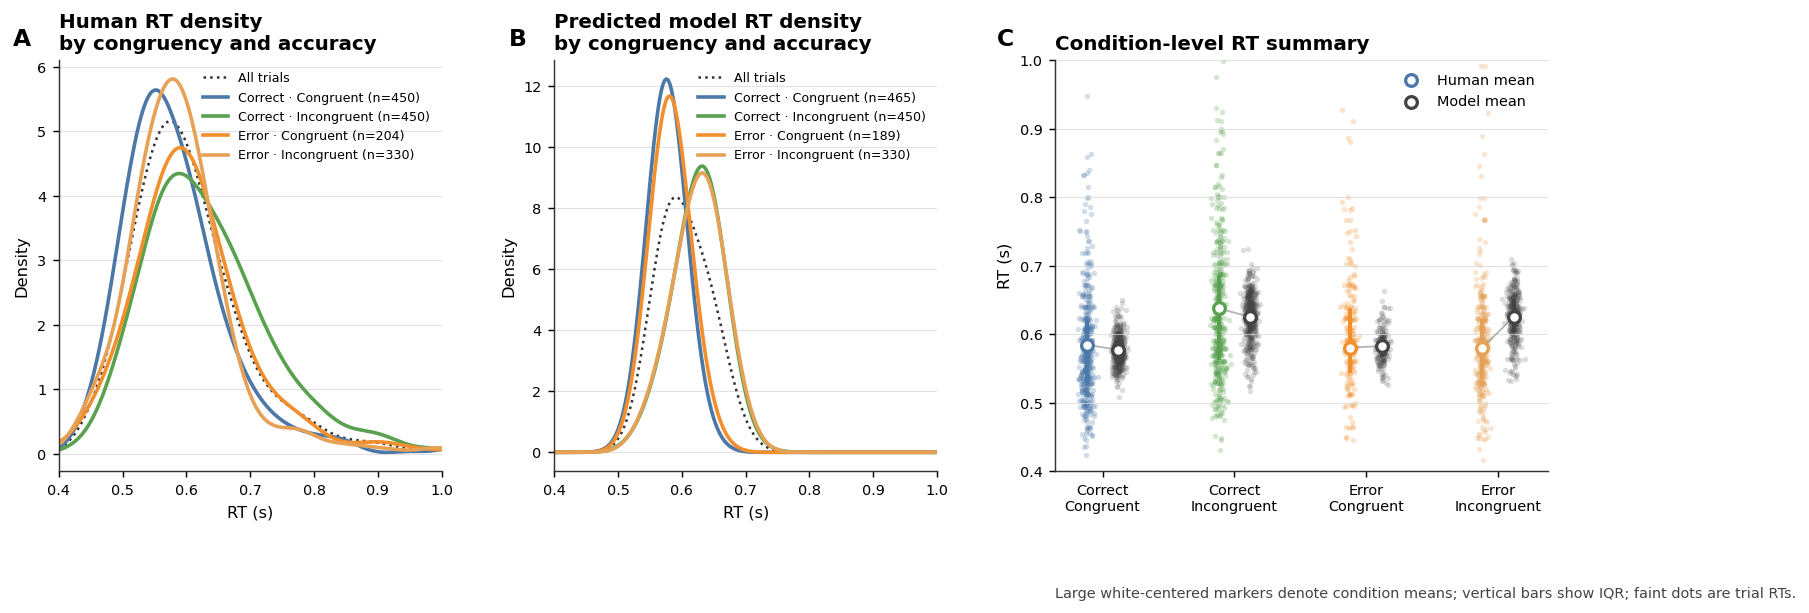

examples/outputs/dmc_var_ww_minimal/example_rt_breakdown.png


In [8]:
def plot_density(ax, df, rt_col, correct_col, title):
    grid = np.linspace(
        RT_PLOT_MIN_SECONDS,
        RT_PLOT_MAX_SECONDS,
        220,
    )
    all_density = gaussian_kde_manual(df[rt_col].to_numpy(), grid)
    ax.plot(grid, all_density, color=COLORS["all_trials"], lw=1.4, ls=":", label="All trials")

    y_for_rug = max(all_density.max() * 0.04, 0.02)
    warned = []
    for congruent, correct, color_key, label in GROUP_SPECS:
        values = df.loc[(df["congruent"] == congruent) & (df[correct_col] == correct), rt_col].to_numpy()
        if len(values) == 0:
            continue
        if len(values) < 5:
            # KDE is unstable for tiny groups, so show only small rug marks.
            ax.scatter(values, np.full_like(values, y_for_rug), marker="|", s=70,
                       color=COLORS[color_key], alpha=0.9, label=f"{label} (n={len(values)}, rug only)")
            warned.append(f"{label}: n={len(values)}")
            continue
        density = gaussian_kde_manual(values, grid)
        ax.plot(grid, density, color=COLORS[color_key], lw=2.0, label=f"{label} (n={len(values)})")
    if warned:
        ax.text(0.02, 0.06, "small-n: KDE skipped\n" + "\n".join(warned),
                transform=ax.transAxes, va="bottom", ha="left", fontsize=7, color="#555555",
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 2.5})
    ax.set_title(title, loc="left")
    ax.set_xlabel("RT (s)")
    ax.set_ylabel("Density")
    ax.set_xlim(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=COLORS["light_gray"], lw=0.6, alpha=0.7)

def plot_condition_summary(ax, df):
    conditions = [
        ("correct_congruent", True, True, "Correct\nCongruent"),
        ("correct_incongruent", False, True, "Correct\nIncongruent"),
        ("error_congruent", True, False, "Error\nCongruent"),
        ("error_incongruent", False, False, "Error\nIncongruent"),
    ]
    x = np.arange(len(conditions))
    rng = np.random.default_rng(SEED)
    for i, (key, congruent, correct, label) in enumerate(conditions):
        sub_h = df.loc[(df["congruent"] == congruent) & (df["human_correct"] == correct), "true_rt"].to_numpy()
        sub_m = df.loc[(df["congruent"] == congruent) & (df["model_correct"] == correct), "pred_rt"].to_numpy()
        if len(sub_h):
            jitter = rng.normal(-0.12, 0.025, size=len(sub_h))
            ax.scatter(np.full(len(sub_h), x[i]) + jitter, sub_h, s=9, color=COLORS[key], alpha=0.25, linewidths=0)
            q1, q3 = np.quantile(sub_h, [0.25, 0.75])
            mean = sub_h.mean()
            ax.vlines(x[i] - 0.12, q1, q3, color=COLORS[key], lw=2.2)
            ax.scatter(x[i] - 0.12, mean, s=42, facecolors="white", edgecolors=COLORS[key], linewidths=1.8, zorder=4)
        if len(sub_m):
            jitter = rng.normal(0.12, 0.025, size=len(sub_m))
            ax.scatter(np.full(len(sub_m), x[i]) + jitter, sub_m, s=9, color="#444444", alpha=0.18, linewidths=0)
            q1, q3 = np.quantile(sub_m, [0.25, 0.75])
            mean_m = sub_m.mean()
            ax.vlines(x[i] + 0.12, q1, q3, color="#444444", lw=2.2)
            ax.scatter(x[i] + 0.12, mean_m, s=42, facecolors="white", edgecolors="#444444", linewidths=1.8, zorder=4)
            if len(sub_h):
                ax.plot([x[i] - 0.12, x[i] + 0.12], [sub_h.mean(), mean_m], color=COLORS["gray"], lw=1.0, alpha=0.75)

    ax.set_xticks(x, [label for _, _, _, label in conditions])
    ax.set_ylabel("RT (s)")
    ax.set_title("Condition-level RT summary", loc="left")
    ax.set_ylim(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=COLORS["light_gray"], lw=0.6, alpha=0.7)
    ax.scatter([], [], s=42, facecolors="white", edgecolors=COLORS["correct_congruent"], linewidths=1.8, label="Human mean")
    ax.scatter([], [], s=42, facecolors="white", edgecolors="#444444", linewidths=1.8, label="Model mean")
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.0))
    ax.text(0.0, -0.28,
            "Large white-centered markers denote condition means; vertical bars show IQR; faint dots are trial RTs.",
            transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#444444")

panel_a_title = (
    "Human RT density\nby congruency and accuracy"
    if not data["is_synthetic"]
    else "Synthetic-human RT density\nby congruency and accuracy"
)

fig, axes = plt.subplots(
    1, 3, figsize=(13.8, 4.6), constrained_layout=True,
    gridspec_kw={"width_ratios": [1.05, 1.05, 1.35], "wspace": 0.08}
)
plot_density(axes[0], predictions, "true_rt", "human_correct", panel_a_title)
plot_density(axes[1], predictions, "pred_rt", "model_correct", "Predicted model RT density\nby congruency and accuracy")
plot_condition_summary(axes[2], predictions)
panel_label(axes[0], "A")
panel_label(axes[1], "B")
panel_label(axes[2], "C")
axes[0].legend(frameon=False, loc="upper right", fontsize=7)
axes[1].legend(frameon=False, loc="upper right", fontsize=7)
breakdown_path = OUTPUT_DIR / "example_rt_breakdown.png"
fig.savefig(breakdown_path, bbox_inches="tight")
plt.show()
print(breakdown_path)

## 9. Save outputs

The notebook writes predictions, metrics, and figures under `examples/outputs/dmc_var_ww_minimal/`.

In [9]:
predictions_path = OUTPUT_DIR / "example_predictions.csv"
metrics_path = OUTPUT_DIR / "example_metrics.json"

public_columns = [
    "trial_index",
    "subject_id_anonymized",
    "target_labels",
    "flanker_labels",
    "response_labels",
    "pred_choice",
    "true_rt",
    "pred_rt",
    "congruency",
    "human_correct",
    "model_correct",
    "split",
    "human_rt",
    "model_rt",
]
public_predictions = predictions[public_columns].copy()
public_predictions.to_csv(predictions_path, index=False)
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print(" -", predictions_path)
print(" -", metrics_path)
print(" -", breakdown_path)
print(" -", dmc_trace_path)

Saved:
 - examples/outputs/dmc_var_ww_minimal/example_predictions.csv
 - examples/outputs/dmc_var_ww_minimal/example_metrics.json
 - examples/outputs/dmc_var_ww_minimal/example_rt_breakdown.png
 - examples/outputs/dmc_var_ww_minimal/example_dmc_traces.png


## Optional extension: temporally correlated evidence noise

The main demo uses independent Gaussian evidence noise at each time step. A useful extension is temporally correlated latent evidence:

`eta_t = rho * eta_{t-1} + sigma_t * epsilon_t`

This borrows the idea of stochastic latent dynamics: momentary evidence is not fully independent from one instant to the next. The extension is disabled by default so the main teaching example stays short and easy to inspect.

In [10]:
RUN_CORRELATED_NOISE_EXTENSION = False

if RUN_CORRELATED_NOISE_EXTENSION:
    with torch.no_grad():
        idx_t = torch.tensor(test_idx[:8], dtype=torch.long, device=DEVICE)
        correlated = model.sampler(
            X[idx_t],
            time_steps=model.time_steps,
            uncertainty_gain=0.75,
            correlated_noise=True,
            rho=0.85,
        )
        independent = model.sampler(
            X[idx_t],
            time_steps=model.time_steps,
            uncertainty_gain=0.75,
            correlated_noise=False,
        )
    print("Correlated evidence shape:", tuple(correlated["evidence_samples"].shape))
    print("Independent evidence shape:", tuple(independent["evidence_samples"].shape))
else:
    print("Extension is off by default. Set RUN_CORRELATED_NOISE_EXTENSION = True to try it.")

Extension is off by default. Set RUN_CORRELATED_NOISE_EXTENSION = True to try it.


## Optional extension: age-group comparison

The main example trains one model for the `20-29` group. The project also studies age-group differences, so the notebook includes a disabled extension hook for young/old comparison.

Set `RUN_AGE_COMPARISON = True` to run the same load → train → evaluate workflow separately for each requested age group. Each age group should train its own model; the groups should not be mixed unless that is explicitly part of the research question.

In [11]:
RUN_AGE_COMPARISON = False
AGE_GROUPS_TO_COMPARE = ["20-29", "80-89"]

if RUN_AGE_COMPARISON:
    age_rows = []
    fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.4), constrained_layout=True)
    axes = axes.ravel()

    for age_i, age_group in enumerate(AGE_GROUPS_TO_COMPARE):
        old_age_group = AGE_GROUP
        AGE_GROUP = age_group
        age_data = _build_real_dataset()
        AGE_GROUP = old_age_group

        if age_data is None:
            age_rows.append({"age_group": age_group, "warning": "missing real data"})
            axes[age_i].set_axis_off()
            continue

        age_trials = age_data["table"].copy()
        age_trials["congruent"] = age_trials["congruency"].astype(bool)
        age_trials["human_rt"] = age_trials["true_rt"]
        age_trials["human_correct"] = age_trials["response_labels"] == age_trials["target_labels"]
        age_trials = age_trials.loc[age_trials["true_rt"].between(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS)]

        # Young panel can reuse the held-out model predictions from the main run.
        if age_group == data["age_group"]:
            model_df = predictions.copy()
            model_df = model_df.loc[model_df["pred_rt"].between(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS)]
            model_rt = model_df["pred_rt"]
            model_available = True
        else:
            model_df = None
            model_rt = pd.Series(dtype=float)
            model_available = False

        grid = np.linspace(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS, 220)
        human_density = gaussian_kde_manual(age_trials["true_rt"].to_numpy(), grid)
        axes[age_i].plot(grid, human_density, color=COLORS["correct_congruent"], lw=2.0, label="Human")
        if model_available and len(model_rt) >= 5:
            model_density = gaussian_kde_manual(model_rt.to_numpy(), grid)
            axes[age_i].plot(grid, model_density, color=COLORS["error_congruent"], lw=2.0, label="Model")
        else:
            axes[age_i].text(0.02, 0.92, "model not trained in this optional comparison",
                             transform=axes[age_i].transAxes, fontsize=8, color="#555555")
        axes[age_i].set_title(f"{age_group} human vs model RT density", loc="left")
        axes[age_i].set_xlim(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS)
        axes[age_i].set_xlabel("RT (s)")
        axes[age_i].set_ylabel("Density")
        axes[age_i].spines[["top", "right"]].set_visible(False)
        axes[age_i].grid(axis="y", color=COLORS["light_gray"], lw=0.6)
        axes[age_i].legend(frameon=False)

        human_error = age_trials.loc[~age_trials["human_correct"], "true_rt"]
        human_correct = age_trials.loc[age_trials["human_correct"], "true_rt"]
        row = {
            "age_group": age_group,
            "n_subjects": age_data["n_subjects"],
            "n_human_trials": int(len(age_trials)),
            "human_mean_rt": float(age_trials["true_rt"].mean()),
            "human_p90_rt": float(age_trials["true_rt"].quantile(0.90)),
            "human_error_minus_correct_rt": None if len(human_error) == 0 else float(human_error.mean() - human_correct.mean()),
            "human_incongruent_minus_congruent_rt": float(
                age_trials.loc[~age_trials["congruent"], "true_rt"].mean()
                - age_trials.loc[age_trials["congruent"], "true_rt"].mean()
            ),
            "model_available": bool(model_available),
            "warning": "" if model_available else "model not trained for this age group in default run",
        }
        if model_available:
            row["model_mean_rt"] = float(model_rt.mean())
            row["model_p90_rt"] = float(model_rt.quantile(0.90))
        age_rows.append(row)

    age_summary = pd.DataFrame(age_rows)
    age_summary_path = OUTPUT_DIR / "age_comparison_summary.csv"
    age_summary.to_csv(age_summary_path, index=False)

    x = np.arange(len(age_summary))
    labels = age_summary["age_group"].tolist()
    axes[2].plot(x, age_summary["human_mean_rt"], color=COLORS["correct_congruent"], marker="o", label="Human mean")
    axes[2].plot(x, age_summary["human_p90_rt"], color=COLORS["correct_incongruent"], marker="o", label="Human p90")
    if "model_mean_rt" in age_summary:
        axes[2].plot(x, age_summary["model_mean_rt"], color=COLORS["error_congruent"], marker="o", label="Model mean")
    axes[2].set_xticks(x, labels)
    axes[2].set_ylim(RT_PLOT_MIN_SECONDS, RT_PLOT_MAX_SECONDS)
    axes[2].set_title("Mean / p90 RT by age group", loc="left")
    axes[2].set_ylabel("RT (s)")
    axes[2].spines[["top", "right"]].set_visible(False)
    axes[2].grid(axis="y", color=COLORS["light_gray"], lw=0.6)
    axes[2].legend(frameon=False)

    width = 0.32
    axes[3].bar(x - width / 2, age_summary["human_error_minus_correct_rt"], width=width,
                color=COLORS["error_congruent"], alpha=0.85, label="Error - correct")
    axes[3].bar(x + width / 2, age_summary["human_incongruent_minus_congruent_rt"], width=width,
                color=COLORS["correct_incongruent"], alpha=0.85, label="Incongruent - congruent")
    axes[3].axhline(0, color=COLORS["gray"], lw=0.8)
    axes[3].set_xticks(x, labels)
    axes[3].set_title("Human RT effects by age group", loc="left")
    axes[3].set_ylabel("RT difference (s)")
    axes[3].spines[["top", "right"]].set_visible(False)
    axes[3].grid(axis="y", color=COLORS["light_gray"], lw=0.6)
    axes[3].legend(frameon=False)

    for letter, ax in zip(["A", "B", "C", "D"], axes):
        panel_label(ax, letter)

    age_fig_path = OUTPUT_DIR / "age_comparison_rt_breakdown.png"
    fig.savefig(age_fig_path, bbox_inches="tight")
    plt.show()
    print("Saved age comparison outputs:")
    print(" -", age_summary_path)
    print(" -", age_fig_path)
else:
    print("Age comparison is off by default to keep the GitHub example fast and reliable.")

Age comparison is off by default to keep the GitHub example fast and reliable.


## 10. Final interpretation

This notebook is an executable pedagogical example.
It uses real held-out human RT/response data when available and demonstrates how the current DMC + variational evidence + Wong-Wang pipeline can be trained and evaluated.

`data input → variational evidence → DMC modulation → Wong-Wang recurrent competition → RT/choice readout → evaluation`

The variational component is VAE-inspired but not a full VAE: there is no image decoder and no standard reconstruction + KL objective. Instead, evidence uncertainty is trained indirectly through behavioral losses, including response prediction, RT prediction, congruency effects, error-vs-correct RT differences, and RT distribution shape.

The goal is not to claim that the minimal notebook model is the final model. The goal is to show how data enter the pipeline, how evidence uncertainty is sampled, how DMC modulates target/flanker evidence over time, how Wong-Wang dynamics generate response and RT, and how the resulting predictions can be compared with human RT distributions.

This notebook does not reproduce the full experimental results and does not claim the current model has reached a final RT distribution fit.